In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [13]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay)

In [4]:
import pandas as pd

df = pd.read_csv(path + "/spam.csv", encoding="latin-1")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (5572, 5)

Columns:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data types:
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object

Missing values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [8]:
df = df[["v1", "v2"]].copy()

df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# Remove rows containing missing values
df.dropna(inplace=True)

# Remove duplicate messages
df.drop_duplicates(inplace=True)

# Reset the index
df.reset_index(drop=True, inplace=True)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (5169, 2)


<Axes: title={'center': 'Distribution of Spam and Ham Messages'}, xlabel='Class', ylabel='Number of Messages'>

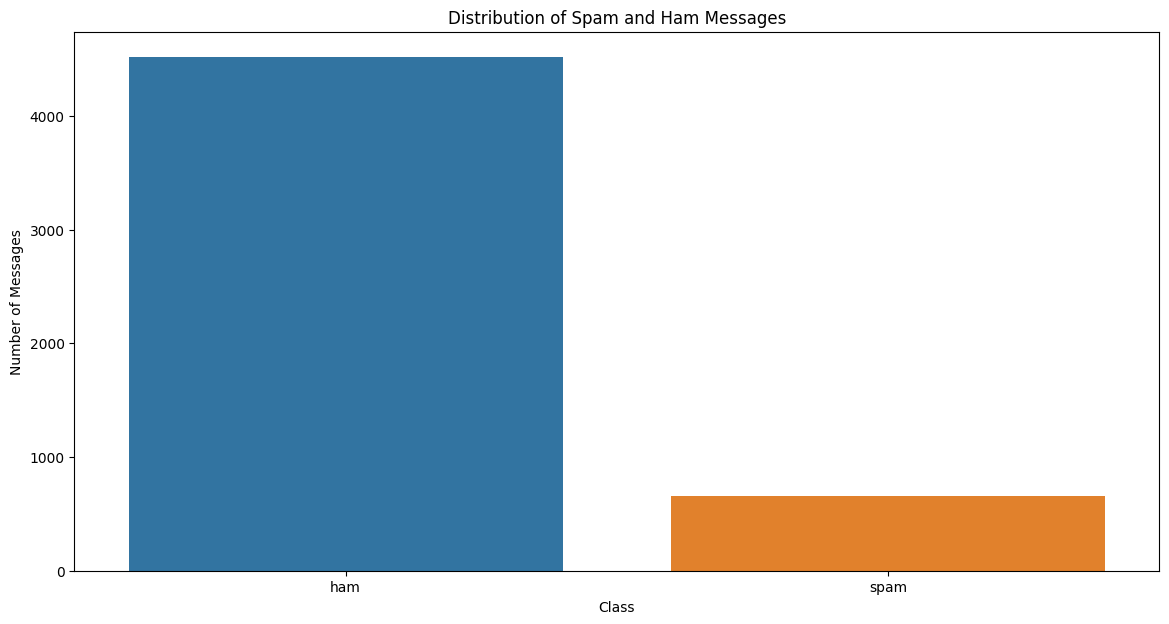

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))
plt.xlabel("Class")
plt.ylabel("Number of Messages")
plt.title("Distribution of Spam and Ham Messages")
sns.countplot(df[['label']],x='label',hue='label')

In [11]:
df['label'] = df['label'].map({
    'ham' : 0,
    'spam' : 1
})

In [20]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [16]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

In [24]:
import re

def preprocess_text(text):
    """
    Preprocess an SMS message using NLTK.

    Steps:
    1. Convert text to lowercase
    2. Tokenize using NLTK
    3. Remove non-alphabetic tokens
    4. Remove English stopwords
    5. Apply Porter stemming
    6. Return the processed text as a string
    """

    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)

    tokens = word_tokenize(text)

    tokens = [
        token
        for token in tokens
        if token.isalpha() and token not in stop_words
    ]

    tokens = [
        stemmer.stem(token)
        for token in tokens
    ]

    return " ".join(tokens)

In [21]:
df["message"] = df["message"].apply(preprocess_text)

X = df["message"]
y = df["label"]

In [23]:
X

,message
0,go jurong point crazi avail bugi n great world...
1,ok lar joke wif u oni
2,free entri wkli comp win fa cup final tkt may ...
3,u dun say earli hor u c alreadi say
4,nah think goe usf live around though
...,...
5164,time tri contact u pound prize claim easi call...
5165,b go esplanad fr home
5166,piti mood suggest
5167,guy bitch act like interest buy someth els nex...


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=34,
    stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3618
Testing samples: 1551


In [26]:
tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1, 2))

In [27]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [28]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [29]:
y_pred = model.predict(X_test_tfidf)

In [30]:
print(classification_report(y_test,y_pred,))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1355
           1       1.00      0.71      0.83       196

    accuracy                           0.96      1551
   macro avg       0.98      0.85      0.90      1551
weighted avg       0.96      0.96      0.96      1551



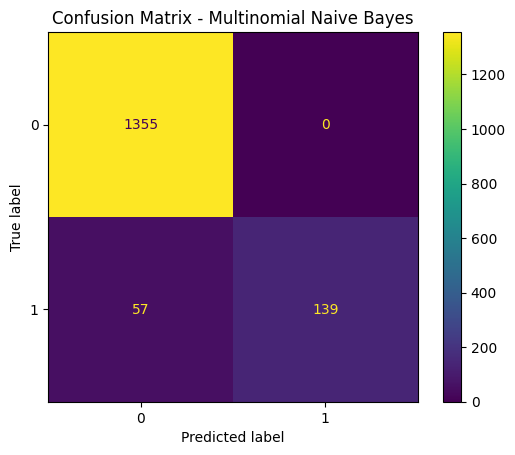

In [31]:
cm_nb = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb,)

disp.plot()
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

In [32]:
def predict_spam(message,model=model):
    """
    Predict whether an SMS message is spam or ham.
    """

    cleaned_message = preprocess_text(message)

    message_tfidf = tfidf.transform([cleaned_message])

    prediction = model.predict(message_tfidf)[0]

    probability = model.predict_proba(message_tfidf)[0].max()

    if prediction == 1:
        label = "SPAM"
    else:
        label = "HAM"

    return label, probability

In [33]:
test_messages = [
    "Congratulations! You have won a free lottery ticket. Call now to claim your prize!",
    "Hey, are we still meeting for lunch today?",
    "URGENT! You have been selected for a cash prize. Reply WIN now!",
    "Please remember to bring the documents tomorrow."
]

for message in test_messages:
    label, probability = predict_spam(message)

    print("Message:", message)
    print("Prediction:", label)
    print(f"Confidence: {probability:.2%}")
    print("-" * 80)

Message: Congratulations! You have won a free lottery ticket. Call now to claim your prize!
Prediction: SPAM
Confidence: 89.95%
--------------------------------------------------------------------------------
Message: Hey, are we still meeting for lunch today?
Prediction: HAM
Confidence: 98.75%
--------------------------------------------------------------------------------
Message: URGENT! You have been selected for a cash prize. Reply WIN now!
Prediction: SPAM
Confidence: 95.22%
--------------------------------------------------------------------------------
Message: Please remember to bring the documents tomorrow.
Prediction: HAM
Confidence: 98.59%
--------------------------------------------------------------------------------
